In [24]:
from statsbombpy import sb
import pandas as pd
import matplotlib.pyplot as plt

# So that pandas don't truncate the tables and all columns can be seen
pd.options.display.max_columns = None
#pd.options.display.max_rows = None

In [25]:
# Checking which competitions are available on statsbomb open data
sb.competitions()

c:\Users\tobia\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,NaN,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882
...,...,...,...,...,...,...,...,...,...,...,...,...
75,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2026-04-11T12:48:10.012987,2021-06-13T16:17:31.694,NaN,2026-04-11T12:48:10.012987
76,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2026-04-27T22:02:42.690507,2026-04-27T22:03:28.087062,2026-04-27T22:03:28.087062,2026-04-27T22:02:42.690507
77,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2026-05-05T03:03:04.199896,2026-05-05T03:05:32.480837,2026-05-05T03:05:32.480837,2026-05-05T03:03:04.199896
78,72,107,International,Women's World Cup,female,False,True,2023,2026-05-03T13:51:31.021141,2026-05-03T13:55:52.303219,2026-05-03T13:55:52.303219,2026-05-03T13:51:31.021141


Loading all available Bundesliga 2023/24 event data via StatsBomb's open data. It only covers Bayer Leverkusen's matches as discovered in the next cell.

In [26]:
bl = sb.competition_events(
    country = "Germany",
    division = "1. Bundesliga",
    season = "2023/2024",
    gender = "male")

c:\Users\tobia\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [27]:
# Confirming the dataset limitations by checking the number of matches.
bl["match_id"].nunique()

34

In [28]:
# Confirming it's Leverkusen and their 17 opponents, not a full 18-club season sample
sorted(bl['team'].unique())

['Augsburg',
 'Bayer Leverkusen',
 'Bayern Munich',
 'Bochum',
 'Borussia Dortmund',
 'Borussia Mönchengladbach',
 'Darmstadt 98',
 'Eintracht Frankfurt',
 'FC Heidenheim',
 'FC Köln',
 'FSV Mainz 05',
 'Freiburg',
 'Hoffenheim',
 'RB Leipzig',
 'Union Berlin',
 'VfB Stuttgart',
 'Werder Bremen',
 'Wolfsburg']

In [29]:
# Total event rows across all 34 matches, about 4000 rows per match shows it does contain huge amounts of information, not only the most important events
len(bl)

137765

Computing Wirtz's minutes played in the season, and checked against FotMob, FBref differs by 5 minutes.

In [30]:
wirtz_id = 40724
wirtz = bl[(bl["player_id"] == wirtz_id) | (bl["substitution_replacement_id"] == wirtz_id)]

# I check below how many times Wirtz was subbed on or off
matches_played = wirtz.groupby(["team", "player", "player_id"]).agg({"match_id":"nunique", "substitution_replacement":"count"})
matches_played.columns = ["played_matches", "subbed_sum"]
matches_played = matches_played.reset_index()
matches_played = matches_played[matches_played["player"] == "Florian Wirtz"]

# Creating a table showing in which minute every replacement including Wirtz occured
min_until_subbed = wirtz[["player", "minute"]][wirtz["substitution_replacement"].isna() == False]
play_as_sub = min_until_subbed["minute"].count()

# Calculating how many minutes Wirtz played before being subbed off 
min_until_subbed_off_sum = min_until_subbed[min_until_subbed["player"] == "Florian Wirtz"]["minute"].sum()

# Calculating how many minutes Wirtz played after being subbed on
min_playing_after_sub_sum = (90 - min_until_subbed[min_until_subbed["player"] != "Florian Wirtz" ]["minute"]).sum()

# Calculating how many matches he played cover to cover
full_matches_played = matches_played[matches_played["player_id"] == wirtz_id]["played_matches"].sum() - play_as_sub

# Calculating those three factors
min_sum = full_matches_played*90 + min_until_subbed_off_sum + min_playing_after_sub_sum
min_sum
#I know, that a match takes longer than 90 minutes, but it's a simplification, and apparently everyone uses it, because what is the chance, that FotMob has exactly the same number of minutes
#and FBref has only 5 mins less


np.int64(2377)

In [31]:
passes = bl.groupby(["team", "player"]).agg({"pass_length":["count", "sum"],
                                             "pass_outcome":"count",
                                             "pass_through_ball":"count",
                                             "pass_shot_assist": "count",
                                             "pass_goal_assist":"count"})

passes.columns = ["num_of_passes", "total_pass_length", "passes_incompleted", "through_balls", "shot_assists", "assists"]
passes = passes.reset_index()
passes = passes[passes["team"] == "Bayer Leverkusen"]
passes["total_pass_length"] = passes["total_pass_length"].round(2)
passes["passes_completed"] = passes["num_of_passes"] - passes["passes_incompleted"]
passes["pass%"] = round(((passes["passes_completed"] / passes["num_of_passes"]) * 100), 2)
passes["length_per_pass"] = round((passes["total_pass_length"] / passes["num_of_passes"]))
passes["mean_successful_pass_length"] = round(((passes["pass%"]/100)*passes["length_per_pass"]))
passes[passes["num_of_passes"] > 999].sort_values(by = "mean_successful_pass_length", ascending=False).head(11)

,team,player,num_of_passes,total_pass_length,passes_incompleted,through_balls,shot_assists,assists,passes_completed,pass%,length_per_pass,mean_successful_pass_length
27,Bayer Leverkusen,Edmond Fayçal Tapsoba,1946,37395.14,163,7,6,1,1783,91.62,19.0,17.0
30,Bayer Leverkusen,Granit Xhaka,3299,57953.39,254,19,41,0,3045,92.30,18.0,17.0
34,Bayer Leverkusen,Jonathan Tah,2167,38531.43,110,0,4,1,2057,94.92,18.0,17.0
41,Bayer Leverkusen,Odilon Kossonou,1422,25168.49,134,6,11,0,1288,90.58,18.0,16.0
43,Bayer Leverkusen,Piero Martín Hincapié Reyna,1423,24357.17,109,3,4,1,1314,92.34,17.0,16.0
35,Bayer Leverkusen,Josip Stanišić,1072,19005.17,109,3,12,1,963,89.83,18.0,16.0
28,Bayer Leverkusen,Exequiel Alejandro Palacios,2022,31396.03,155,9,23,4,1867,92.33,16.0,15.0
33,Bayer Leverkusen,Jonas Hofmann,1528,26917.23,289,5,69,7,1239,81.09,18.0,15.0
44,Bayer Leverkusen,Robert Andrich,1501,26035.87,142,5,19,2,1359,90.54,17.0,15.0
23,Bayer Leverkusen,Alejandro Grimaldo García,2159,35993.96,376,15,63,13,1783,82.58,17.0,14.0


Note on xA discrepancy: this notebook's computed xA for Wirtz (7.73) sits below three external figures found for this season (12.73, 9, 8.5). Two things were investigated directly:

1. Assist count (10 here vs. 11 every different website) - resolved. One of Wirtz's assists came from a shot that deflected off the post and in off the goalkeeper; 
StatsBomb classifies this as an "Own Goal For" event, which is separate from the Shot event chain and has no xG value or link back to the assisting pass. 
External sites likely use official match records (scorer + assist rom the box score) rather than StatsBomb's structured event chain, so they still credit the assist;
this dataset structurally cannot.

2. Qualifying pass count (71 shot-assisting passes here) - checked, and not the issue.
External sources report a range of 61-75 key passes for Wirtz this season;
71 sits comfortably inside that range, so the input to the xA sum isn't unusually high or low.

Given both of those check out, the remaining gap most likely comes down to differences in the underlying xG model itself - StatsBomb, 
and each external source, calculate shot quality differently, so the same 71 shots can sum to different total xA depending on whose model is doing the scoring. 
This wasn't independently verified further, since StatsBomb doesn't publish shot-by-shot xG comparisons against other providers.

In [32]:
# I will take only rows with a pass that assisted a shot
every_assist = bl[(bl["pass_assisted_shot_id"].isna() == False) & (bl["team"] == "Bayer Leverkusen")][["player_id", "player", "team", "pass_assisted_shot_id"]]
# I will search only for Leverkusen's players shots, by shot_body_part (but I can take here anything that will have a shot value and load the xG)
every_shot = bl[(bl["team"] == "Bayer Leverkusen") & (bl["type"] == "Shot")][["shot_outcome", "id", "shot_statsbomb_xg"]]
# I merge two tables into one, by id of the shot and use left merge because I want only the shots that were assisted
merged = pd.merge(
    left = every_assist,
    right = every_shot,
    left_on = "pass_assisted_shot_id",
    right_on = "id",
    how = "left"
)
xA = merged.groupby(["player_id", "player"]).agg({"shot_statsbomb_xg":"sum"})
xA.columns = ["xAssists"]
xA = xA.reset_index()
xA = xA[["player_id", "player", "xAssists"]].sort_values(by = "xAssists", ascending = False)
xA
#xA = 7.732809 which seems very low compared to independent data sources

,player_id,player,xAssists
6,10336.0,Alejandro Grimaldo García,9.147892
4,8804.0,Jonas Hofmann,7.839494
16,40724.0,Florian Wirtz,7.732809
13,32712.0,Jeremie Frimpong,4.543442
12,32289.0,Victor Okoh Boniface,3.831032
10,28268.0,Exequiel Alejandro Palacios,3.334345
0,3500.0,Granit Xhaka,2.605642
14,33401.0,Amine Adli,2.436795
17,41411.0,Nathan Tella,2.331407
5,9195.0,Robert Andrich,1.786079


### Minutes played, for the full Bayer Leverkusen squad

Extending the Wirtz-only method above to every player. StatsBomb's event data has no built-in 
minutes column, so this is derived from Starting XI, Substitution, and match structure: full 
matches played × 90, plus partial minutes for players subbed on or off mid-match. 

Players with no substitution involvement (e.g. the goalkeeper) initially produced NaN values after 
merging - fixed with `.fillna(0)`, since "never subbed" correctly means zero substitution-related 
minutes, not missing data.

In [33]:
# Count matches each player appeared in, and how many times they were subbed off
matches_played = bl[(bl["team"] == "Bayer Leverkusen")].groupby(["team", "player_id", "player"]).agg({"match_id":"nunique", "substitution_replacement":"count"})
matches_played.columns = ["played_matches", "subbed_off_sum"]
matches_played = matches_played.reset_index()

# Count how many times each player was subbed on (as a substitute)
subbed_on = bl[bl["team"] == "Bayer Leverkusen"].groupby("substitution_replacement").agg({"player":"count"})
subbed_on = subbed_on.fillna(value = 0)
subbed_on = subbed_on.reset_index()
subbed_on.columns = ["player", "subbed_on_sum"]

# Minutes played before being subbed off, summed per player
min_until_subbed_off = bl[bl["team"] == "Bayer Leverkusen"][bl["substitution_replacement"].isna() == False].groupby("player").agg({"minute":"sum"})
min_until_subbed_off.columns = ["mins_until_subbed_off"]
min_until_subbed_off = min_until_subbed_off.reset_index()

# Minutes played after coming on as a substitute (90 - the minute they entered)
min_after_subbed_on = bl[(bl["team"] == "Bayer Leverkusen") & (bl["substitution_replacement"].isna() == False)][["substitution_replacement", "minute"]].groupby("substitution_replacement").agg({"minute":"sum"})
min_after_subbed_on["subbed_on_sum"] = bl[bl["team"] == "Bayer Leverkusen"].groupby("substitution_replacement").agg({"substitution_replacement":"count"})
min_after_subbed_on.columns = ["mins_in_progress", "times_subbed_on"]
min_after_subbed_on = min_after_subbed_on.reset_index()
min_after_subbed_on["min_after_subbed_on"] = min_after_subbed_on["times_subbed_on"]*90 - min_after_subbed_on["mins_in_progress"]
min_after_subbed_on = min_after_subbed_on.drop(labels = ["mins_in_progress", "times_subbed_on"], axis = 1)

# Combine all pieces; players never involved in a substitution get NaN here - fill with 0
combined = pd.merge(
    left = matches_played,
    right = subbed_on,
    left_on = "player",
    right_on = "player",
    how = "left")
combined = combined.fillna(value = 0)
combined["matches_fully_played"] = combined["played_matches"] - combined["subbed_off_sum"] - combined["subbed_on_sum"]
combined["full_matches_min"] = combined["matches_fully_played"]*90
combined = pd.merge(
    left = combined,
    right = min_until_subbed_off,
    left_on = "player",
    right_on = "player",
    how = "left")
combined = combined.fillna(value = 0)
combined = pd.merge(
    left = combined,
    right = min_after_subbed_on,
    left_on = "player",
    right_on = "substitution_replacement",
    how = "left")
combined = combined.drop(labels = ["team", "substitution_replacement"], axis =1)
combined = combined.fillna(value = 0)

# Total minutes = full matches + partial matches (subbed off) + partial matches (subbed on)
combined["total_min"] = combined["full_matches_min"] + combined["mins_until_subbed_off"] + combined["min_after_subbed_on"]
combined["per90"] = round(combined["total_min"]/90, 1)
per_90 = combined.drop(labels = ["played_matches", "subbed_off_sum", "subbed_on_sum", "matches_fully_played", "full_matches_min", "mins_until_subbed_off", "min_after_subbed_on"], axis = 1)
per_90

C:\Users\tobia\AppData\Local\Temp\ipykernel_4144\2279777430.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  min_until_subbed_off = bl[bl["team"] == "Bayer Leverkusen"][bl["substitution_replacement"].isna() == False].groupby("player").agg({"minute":"sum"})


,player_id,player,total_min,per90
0,3500.0,Granit Xhaka,2821.0,31.3
1,7044.0,Patrik Schick,1062.0,11.8
2,8221.0,Jonathan Tah,2631.0,29.2
3,8403.0,Nadiem Amiri,81.0,0.9
4,8667.0,Lukáš Hrádecký,2970.0,33.0
5,8804.0,Jonas Hofmann,2205.0,24.5
6,9195.0,Robert Andrich,1689.0,18.8
7,10336.0,Alejandro Grimaldo García,2785.0,30.9
8,11391.0,Borja Iglesias Quintas,255.0,2.8
9,27133.0,Odilon Kossonou,1811.0,20.1


### Calculating amount of Through Balls per 90 minutes played by each player
I calculated the Through Balls for each player and then divided by 90 minutes played from the table above.
Florian Wirtz was the leading "Through-Ball" passer among his teammates that season

Text(0.5, 1.0, 'Through Balls per 90 by each player')

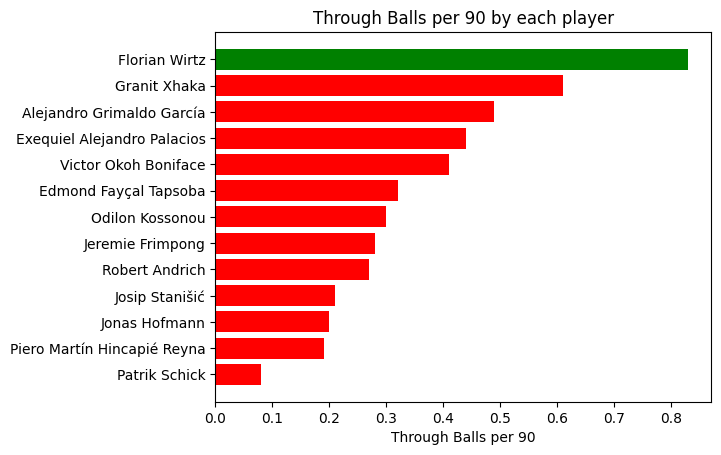

In [34]:
# Calculating how many through balls each player had
through_balls = bl[(bl["pass_technique"] == "Through Ball") & (bl["team"] == "Bayer Leverkusen")][["player", "player_id", "pass_technique"]].groupby(["player_id"]).agg({"pass_technique":"count"})
through_balls.columns = ["Through Balls"]
through_balls = through_balls.reset_index()

# Merging with per 90 table, so I can calculate Through Balls per 90
through_balls_per90 = pd.merge(
    left = per_90,
    right = through_balls,
    left_on = "player_id",
    right_on = "player_id",
    how = "right")

through_balls_per90["Through Balls per 90"] = round(through_balls_per90["Through Balls"] / through_balls_per90["per90"], 2)
through_balls_per90 = through_balls_per90[through_balls_per90["total_min"] > 999].sort_values(by = "Through Balls per 90", ascending = True)

for_chart = through_balls_per90.drop(labels = ["player_id", "total_min", "per90", "Through Balls"], axis = 1)

# For loop that will set the color of Wirtz's bar green, and the rest of the teammates red, so it can highlight the object of the research
colors = []
for _, row in for_chart.iterrows():
    if row["player"] == "Florian Wirtz":
        colors.append("green")
    else:
        colors.append("red")
# Creating a bar chart showing Wirtz's superiority in this particular field
plt.barh(y=for_chart["player"], width = for_chart["Through Balls per 90"], color = colors)
plt.xlabel("Through Balls per 90")
plt.title("Through Balls per 90 by each player")


### Expected assists per 90
I took xA and per_90 tables from above, merged them and calculated the xA per 90 values. 
Florian Wirtz, alongside Jonas Hofmann and Alejandro Grimaldo was the main chance creation force for Bayer Leverkusen that season. 

Text(0.5, 1.0, 'Expected Assists by player per 90 minutes played')

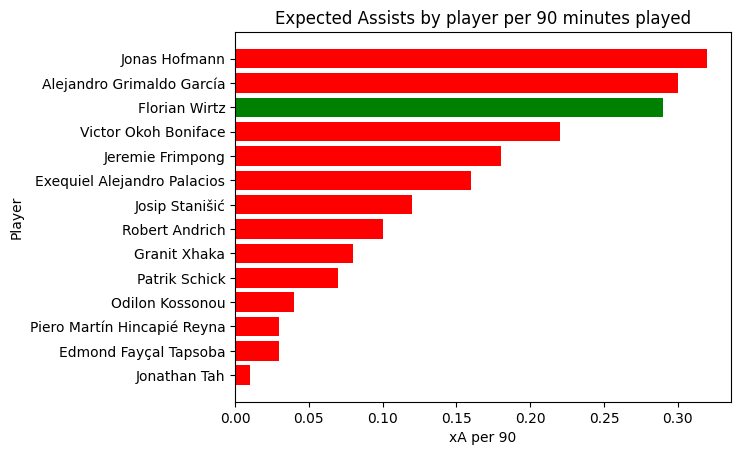

In [35]:
# Merging tables xA and per_90 so that I can calculate xA per 90 minutes played
xA_per90 = pd.merge(
    left = xA,
    right = per_90,
    left_on = "player_id",
    right_on = "player_id",
    how = "left")
xA_per90 = xA_per90.drop(labels = "player_y", axis = 1)
xA_per90.columns = ["player_id", "player", "xA", "total_min", "per90"]
xA_per90["xA per 90"] = round(xA_per90["xA"]/xA_per90["per90"], 2)
# Removing players who played less than 1000 minutes in order to avoid distortion among the results
xA_per90 = xA_per90[xA_per90["total_min"] > 999].sort_values(by = "xA per 90", ascending = True)
for_chart = xA_per90.drop(labels = ["player_id", "total_min", "per90"], axis = 1)

colors = []
for _, row in for_chart.iterrows():
    if row["player"] == "Florian Wirtz":
        colors.append("green")
    else:
        colors.append("red")
plt.barh(y=for_chart["player"], width = for_chart["xA per 90"], color = colors)
plt.xlabel("xA per 90")
plt.ylabel("Player")
plt.title("Expected Assists by player per 90 minutes played")

### Correlation between the amount of Key Passes and xA created
Scatter plot shows the strong correlation between passes leading to a shot and xA created.
Florian Wirtz isn't an outlier. 

Text(0.5, 0, 'xA per 90')

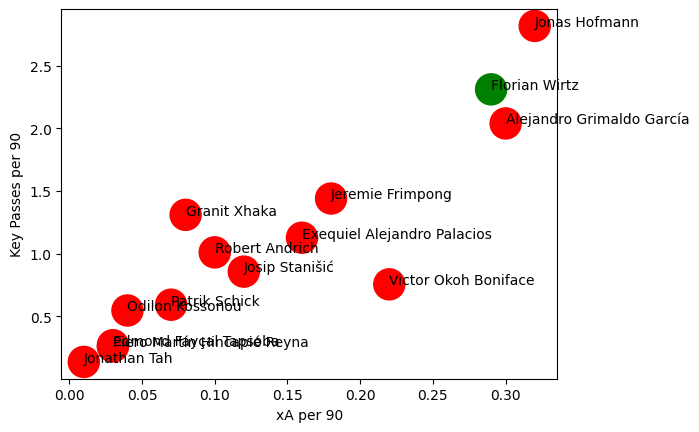

In [36]:
key_passes = bl[bl["team"] == "Bayer Leverkusen"].groupby("player").agg({"pass_shot_assist":"count"})
key_passes.columns = ["Key Passes"]
key_passes = key_passes.reset_index()
combined = pd.merge(
    left = xA_per90,
    right = key_passes,
    left_on = "player",
    right_on = "player",
    how = "left")
combined["Key Passes per 90"] = combined["Key Passes"]/combined["per90"]
combined_chart = combined.drop(labels = ["player_id", "total_min", "per90", "Key Passes"], axis = 1)
colors = []
for _, row in for_chart.iterrows():
    if row["player"] == "Florian Wirtz":
        colors.append("green")
    else:
        colors.append("red")
plt.scatter(x = combined_chart["xA per 90"], y = combined_chart["Key Passes per 90"], color = colors, s = 500)
for _, row in combined_chart.iterrows():
    plt.annotate(row["player"], (row["xA per 90"], row["Key Passes per 90"]))
plt.ylabel("Key Passes per 90")
plt.xlabel("xA per 90")

### Investigating the manner of Through Balls passed by Bayer Leverkusen players
The object of this bar plot is to investigate how many through came from build-up phase, and how many of them came from counter.
The small amount of through balls from counter means I couldn't exctract any useful information, but it gave me an information of Bayer Leverkusen being very dominant team in terms of possession.
As viewed below, Florian Wirtz particuralry excells in the amount of Through Balls from build-up.

Text(0.5, 0, 'Through Balls from build-up per 90')

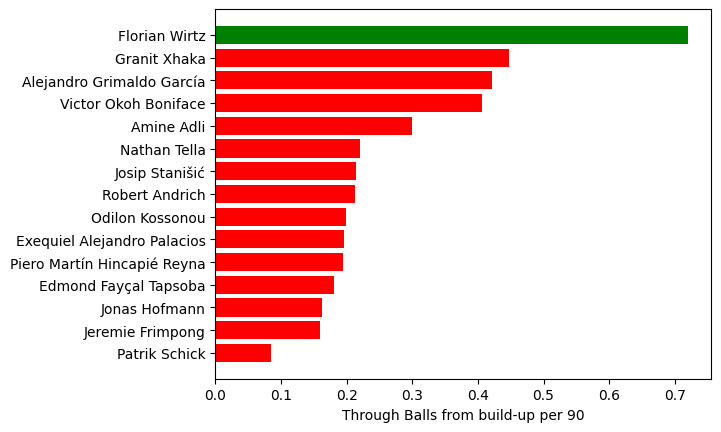

In [37]:
tb_from_counter = bl[(bl["play_pattern"] == "From Counter") & (bl["pass_technique"] == "Through Ball") & (bl["team"] == "Bayer Leverkusen")].groupby(["player_id", "player"]).agg({"pass_technique":"count"})
tb_from_counter.columns = ["Through balls from counter"]
tb_from_counter = tb_from_counter.reset_index()
tb_from_buildup = bl[(bl["play_pattern"].isin(["Regular Play", "From Goal Kick", "From Keeper", "From Throw In"])) & (bl["pass_technique"] == "Through Ball") & (bl["team"] == "Bayer Leverkusen")].groupby(["player_id", "player"]).agg({"pass_technique":"count"})
tb_from_buildup.columns = ["Through ball from build-up"]
tb_from_buildup = tb_from_buildup.reset_index()
comparison = pd.merge(
    left = tb_from_counter,
    right = tb_from_buildup,
    left_on = "player_id",
    right_on  = "player_id",
    how = "outer")
comparison = comparison.drop(labels = "player_x", axis=1)
comparison = comparison.loc[:, ["player_id", "player_y", "Through balls from counter", "Through ball from build-up"]]
comparison.columns = ["player_id", "player", "Through balls from counter", "Through balls from build-up"]
comparison = comparison.fillna(value = 0)
comparison = pd.merge(
    left = comparison,
    right = per_90,
    left_on = "player_id",
    right_on = "player_id",
    how = "left")
comparison = comparison.drop(labels = ["player_y", "total_min"], axis=1)
comparison["TB from counter/90"] = round(comparison["Through balls from counter"]/comparison["per90"], 3)
comparison["TB from build-up/90"] = round(comparison["Through balls from build-up"]/comparison["per90"], 3)
comparison = comparison.drop(labels = "per90", axis = 1)
comparison = comparison.loc[:, ["player_id", "player_x", "Through balls from counter", "TB from counter/90", "Through balls from build-up", "TB from build-up/90"]]
comparison = comparison.sort_values(by = "TB from build-up/90", ascending = True)
colors = []
for _, row in comparison.iterrows():
    if row["player_x"] == "Florian Wirtz":
        colors.append("green")
    else:
        colors.append("red")
bar_chart = plt.barh(y = comparison["player_x"], width = comparison["TB from build-up/90"], color = colors)
plt.xlabel("Through Balls from build-up per 90")

In [38]:
# Checking if Wirtz won a penalty for the next measure
wirtz[wirtz["foul_won_penalty"] == True]
# He didn't so I don't need to add this condition

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_other,clearance_right_foot,counterpress,dribble_no_touch,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_shot_saved_off_target,goalkeeper_shot_saved_to_post,goalkeeper_success_in_play,goalkeeper_success_out,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_straight,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_open_goal,shot_outcome,shot_saved_off_target,shot_saved_to_post,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure


### Wirtz actions
I created a measure competing with per 90 stats, because I wanted to see how many times Wirtz dribbles per action, meaning everytime he got the ball, until he lost the ball. The problem was, that there are so many actions across the season, it is hard to exctract any meaningful conclusion, and the numbers are very low.

In [39]:
wirtz_actions = wirtz[(wirtz["type"].isin(values = ["Dispossessed", "Shot", "Foul Won", "Pass", "Miscontrol", "Injury Stoppage", "Error", "Duel", "Dribble"])) 
      & ((wirtz["duel_outcome"] != "Won") & (wirtz["dribble_outcome"] != "Complete"))]["type"].count()
wirtz_actions

np.int64(2235)

In [40]:
wirtz_dribbles = wirtz[wirtz["type"] == "Dribble"]["type"].count()
dribbles_per_action = round(wirtz_dribbles/wirtz_actions, 3)
dribbles_per_action

np.float64(0.054)

### Dribbles per 90
I have used pretty similar technique to the previous ones to calculate amount of dribbles made by Bayer Leverkusen players during the 2023/2024 season.
Florian Wirtz is the second most dribbling Bayer Leverkusen player per 90, with only Victor Boniface having more.

Text(0.5, 0, 'Dribbles per 90')

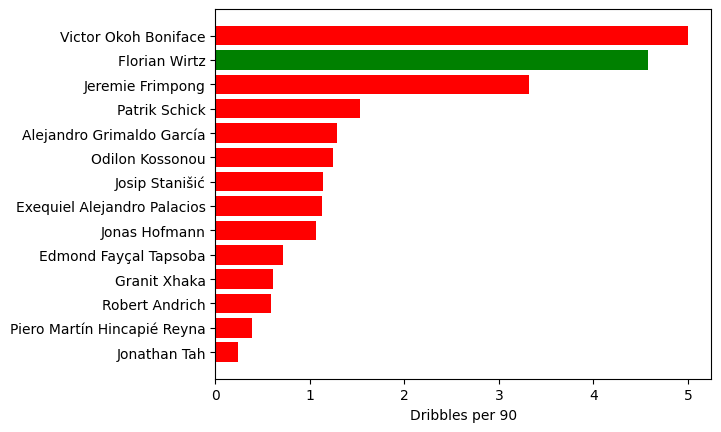

In [41]:
dribbles = bl[(bl["type"] == "Dribble") & (bl["team"] == "Bayer Leverkusen")].groupby("player").agg({"type":"count"})
dribbles.columns = ["Dribbles"]
dribbles = dribbles.reset_index()
dribbles_per90 = pd.merge(
    left = dribbles,
    right = per_90,
    left_on = "player",
    right_on = "player",
    how = "left"
)
dribbles_per90["Dribbles per 90"] = round(dribbles_per90["Dribbles"]/dribbles_per90["per90"], 2)
dribbles_per90 = dribbles_per90[(dribbles_per90["total_min"] > 999)].sort_values(by = "Dribbles per 90", ascending = True)
colors = []
for _, row in dribbles_per90.iterrows():
    if row["player"] == "Florian Wirtz":
        colors.append("green")
    else:
        colors.append("red")
bar_chart = plt.barh(y = dribbles_per90["player"], width = dribbles_per90["Dribbles per 90"], color = colors)
plt.xlabel("Dribbles per 90")

### Correlation between amount of dribbles per 90 and success rate
There is **no correlation** between the amount of dribbles per 90 and its success rate. My assumption is, it might depend purely on the player's ability and the environment around him in every take-on action. Or it might be the position, because the results spread differently across the roles in the squad.

Text(0, 0.5, 'Dribbles per 90')

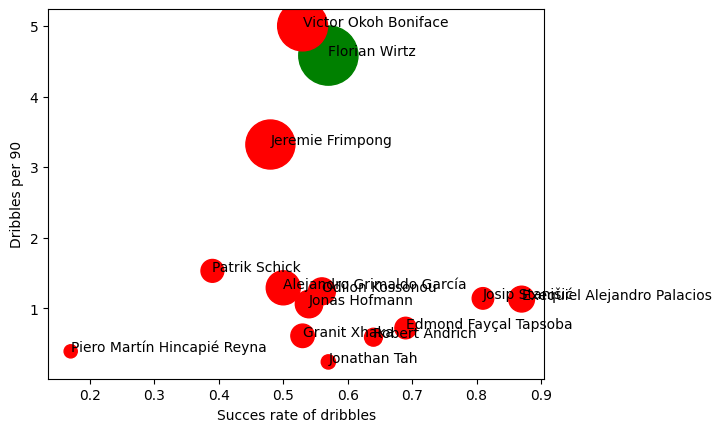

In [42]:
succ_dribbles = bl[(bl["dribble_outcome"] == "Complete") & (bl["team"] == "Bayer Leverkusen")].groupby("player").agg({"dribble_outcome":"count"})
succ_dribbles.columns = ["Successful Dribbles"]
succ_dribbles = succ_dribbles.reset_index()
for_plot = pd.merge(
    left = dribbles_per90,
    right = succ_dribbles,
    left_on = "player",
    right_on = "player",
    how = "left")

for_plot["Success Rate"] = round(for_plot["Successful Dribbles"]/ for_plot["Dribbles"], 2)
colors = []
for _, row in for_plot.iterrows():
    if row["player"] == "Florian Wirtz":
        colors.append("green")
    else:
        colors.append("red")
plot = plt.scatter(x = for_plot["Success Rate"], y = dribbles_per90["Dribbles per 90"], color = colors, s = for_plot["Dribbles"]*15)
for _, row in for_plot.iterrows():
    plt.annotate(row["player"], (row["Success Rate"], row["Dribbles per 90"]))
plt.xlabel("Succes rate of dribbles")
plt.ylabel("Dribbles per 90")